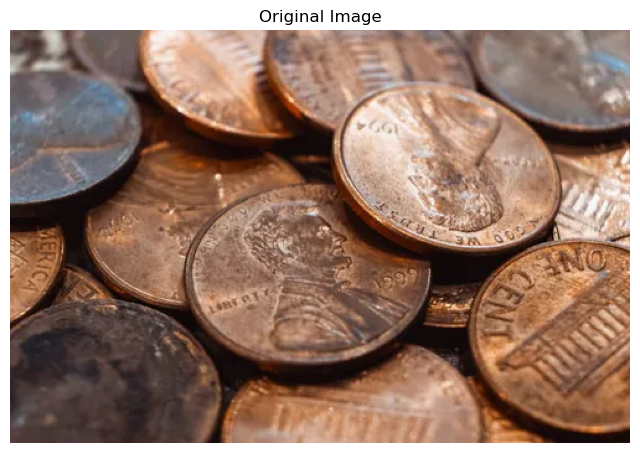

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread("coin.png")

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")
plt.show()

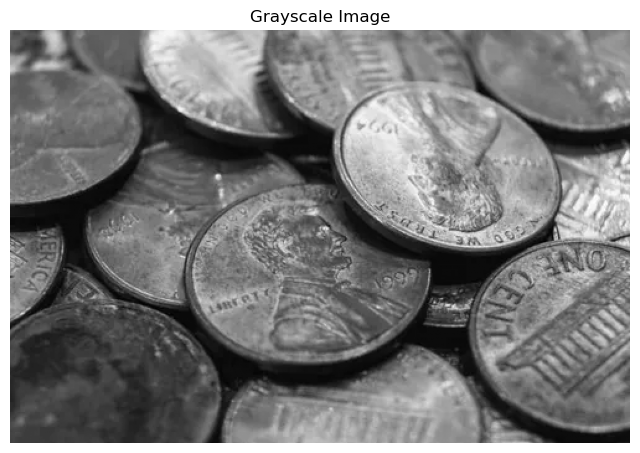

In [10]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8, 6))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

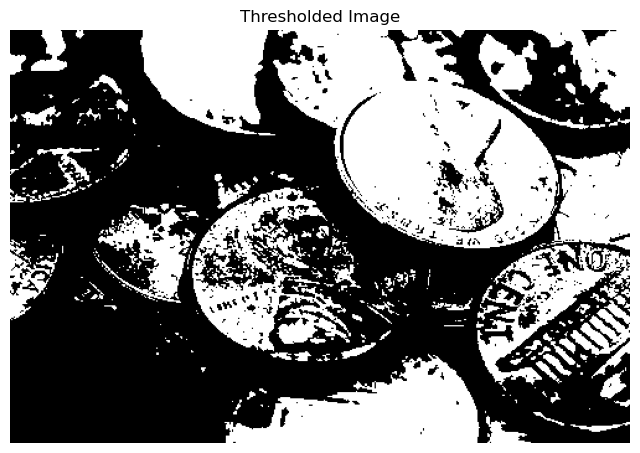

In [11]:
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(8, 6))
plt.imshow(thresh, cmap="gray")
plt.title("Thresholded Image")
plt.axis("off")
plt.show()

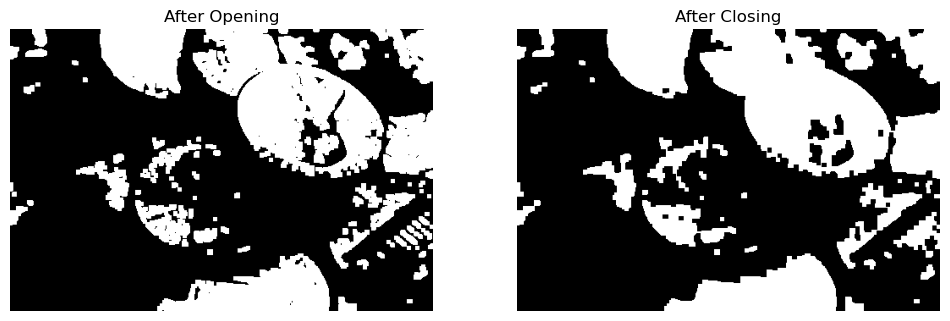

In [12]:
kernel = np.ones((5, 5), np.uint8)

# Opening - removes small noise
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

# Closing - fills small holes
closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(opening, cmap="gray")
plt.title("After Opening")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(closing, cmap="gray")
plt.title("After Closing")
plt.axis("off")

plt.show()

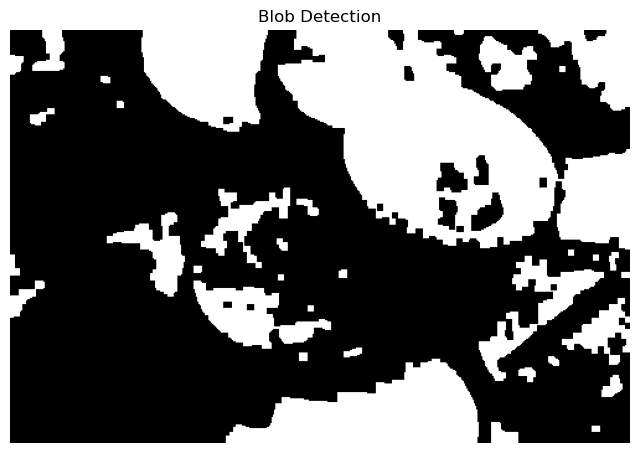

Number of coins detected using Blob Detection: 0


In [13]:
params = cv2.SimpleBlobDetector_Params()

params.filterByArea = True
params.minArea = 500
params.maxArea = 50000

params.filterByCircularity = True
params.minCircularity = 0.7

params.filterByConvexity = True
params.minConvexity = 0.8

params.filterByInertia = True
params.minInertiaRatio = 0.5

detector = cv2.SimpleBlobDetector_create(params)

keypoints = detector.detect(closing)

blob_image = cv2.drawKeypoints(
    cv2.cvtColor(closing, cv2.COLOR_GRAY2BGR),
    keypoints,
    None,
    (0, 0, 255),
    cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(blob_image, cv2.COLOR_BGR2RGB))
plt.title("Blob Detection")
plt.axis("off")
plt.show()

print("Number of coins detected using Blob Detection:", len(keypoints))

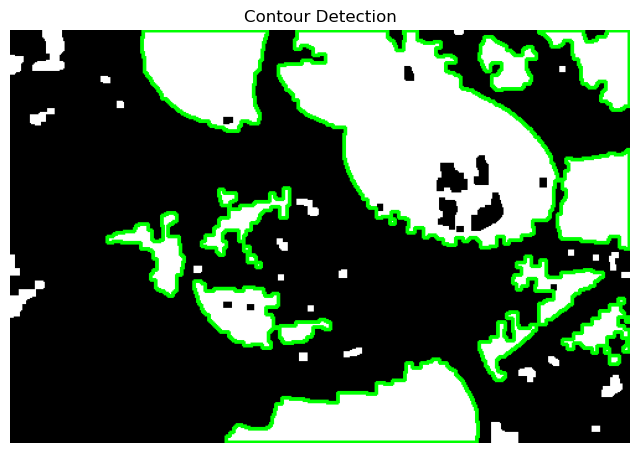

Number of coins detected using Contours: 10


In [14]:
contours, hierarchy = cv2.findContours(
    closing,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# Filter small contours
coin_contours = []

for contour in contours:
    area = cv2.contourArea(contour)
    
    if area > 500:
        coin_contours.append(contour)

# Draw contours
contour_image = cv2.cvtColor(closing, cv2.COLOR_GRAY2BGR)

cv2.drawContours(
    contour_image,
    coin_contours,
    -1,
    (0, 255, 0),
    2
)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(contour_image, cv2.COLOR_BGR2RGB))
plt.title("Contour Detection")
plt.axis("off")
plt.show()

print("Number of coins detected using Contours:", len(coin_contours))

In [15]:
print("===== RESULTS =====")
print("Coins detected using Blob Detection    :", len(keypoints))
print("Coins detected using Contour Detection :", len(coin_contours))

===== RESULTS =====
Coins detected using Blob Detection    : 0
Coins detected using Contour Detection : 10
